安装需要的库

In [ ]:
# # 1. 数据基础库
# %pip install numpy pandas

# # 2. 可视化库
# %pip install matplotlib seaborn

# # 3. 机器学习库
# %pip install scikit-learn

# # 4. 统计分析库
# %pip install statsmodels scipy


In [1]:
# 数据处理和科学计算库
import numpy as np
import pandas as pd

# 可视化库
import matplotlib.pyplot as plt
import seaborn as sns

# 机器学习库
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 统计分析库
import statsmodels.api as sm
from scipy import stats

# 设置可视化风格
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

生成数据以及探索性分析

In [4]:
# 设置随机种子确保结果可复现
np.random.seed(42)


# 生成100个学生的随机学习时间：np.random的uniform函数 参数：下限；上限；数量
study_hours = np.random.uniform(1,10,100).reshape(-1,1)
# 生成带有噪音的100个成绩数据：噪音————np.random的normal函数 参数：均值；标准差；数量
exam_scores = np.random.normal(0,5,100).reshape(-1,1) + 30 +7 * study_hours

# 将数据转化为dataframe
data = pd.DataFrame({'Study_hours':study_hours.flatten(),'Exam_scores':exam_scores.flatten()})

In [5]:
print('数据前五行')
print(data.head())
print('数据统计信息')
print(data.describe())

数据前五行
   Study_hours  Exam_scores
0     4.370861    61.031263
1     9.556429    95.399965
2     7.587945    83.574422
3     6.387926    64.777640
4     2.404168    45.730815
数据统计信息
       Study_hours  Exam_scores
count   100.000000   100.000000
mean      5.231627    66.615985
std       2.677405    18.613373
min       1.049699    35.252198
25%       2.738807    51.021252
50%       5.177282    64.403856
75%       7.571828    83.145015
max       9.881982   103.082991


数据可视化：散点图

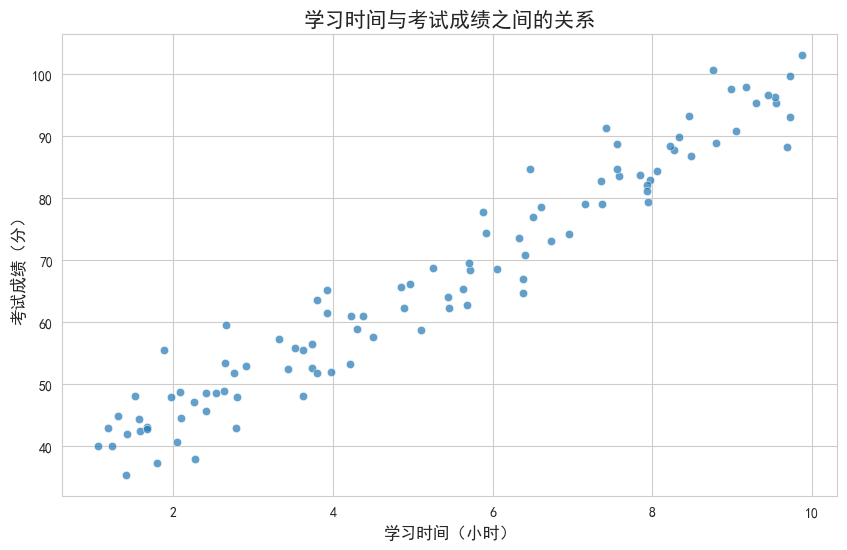

In [7]:
# 创建画布：使用matplotlib的figure函数，参数：figsize画布大小比例
plt.figure(figsize=(10,6))

# 绘制散点:用seaborn里的scatterplot函数，参数为：x，y轴含义；数据来源（dataframe）；透明度
sns.scatterplot(x='Study_hours',y='Exam_scores',data=data,alpha=0.7)

# 设置标题
plt.title('学习时间与考试成绩之间的关系',fontsize=15)

# 设置x和y轴标签
plt.xlabel('学习时间（小时）',fontsize=12)
plt.ylabel('考试成绩（分）',fontsize=12)

# 显示图形
plt.show()

计算相关系数

In [8]:
correlation = data['Study_hours'].corr(data['Exam_scores'])
print(f'相关系数为{correlation}') 

相关系数为0.970159704333297


划分训练集和测试集

In [9]:
# 定义自变量X和因变量Y
X = data[['Study_hours']]  # 自变量必须二维
Y = data['Exam_scores']

# 将数据按比例划分为训练集和测试集
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,  # 测试集占比
    random_state=42  # 随机种子
)

print(f'训练集大小：{X_train.shape[0]}')
print(f'测试集大小：{X_test.shape[0]}')

训练集大小：80
测试集大小：20


模型训练，用scikit-learn中的LinearRegression类

In [10]:
# 1 创建线性回归模型实例
model = LinearRegression()

# 2 使用训练数据来训练模型
model.fit(X_train,Y_train)

# 3 获取模型参数
intercept = model.intercept_   # 截距
slope = model.coef_[0]   #斜率  coef输出的是一维数组，里面包含每个特征的系数

print(f'模型训练完成!')
print(f'截距 (beta_0): {intercept:.4f}')
print(f'斜率 (beta_1): {slope:.4f}')

print('回归方程为:')
print(f'Exam_Scores = {intercept:.2f} + {slope:.2f} * Study_Hours')

模型训练完成!
截距 (beta_0): 30.9375
斜率 (beta_1): 6.7770
回归方程为:
Exam_Scores = 30.94 + 6.78 * Study_Hours


模型预测和评估

In [11]:
# 在测试集上预测
Y_pred = model.predict(X_test)

# 将预测的结果和实际结果放在一个dataframe里比较
prediction_df = pd.DataFrame({'Actual':Y_test,'Predict':Y_pred})

print("测试集上的预测结果 vs 实际结果:")
print(prediction_df.head())

测试集上的预测结果 vs 实际结果:
       Actual    Predict
83  44.286944  41.591196
53  90.856745  92.292983
70  79.466667  84.816275
45  74.191967  78.123945
44  57.258299  53.498395


计算评估指标

In [12]:
# 计算R²
r2 = r2_score(Y_test,Y_pred)
# 计算MSE
mse = mean_squared_error(Y_test,Y_pred)
# 计算RMSE
rmse = np.sqrt(mse)
# 计算MAE
mae = mean_absolute_error(Y_test,Y_pred)

print(f'--- 模型在测试集上的评估结果 ---')
print(f'R-squared (R²): {r2:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')

--- 模型在测试集上的评估结果 ---
R-squared (R²): 0.9553
Mean Squared Error (MSE): 16.3425
Root Mean Squared Error (RMSE): 4.0426
Mean Absolute Error (MAE): 2.9567


结果可视化

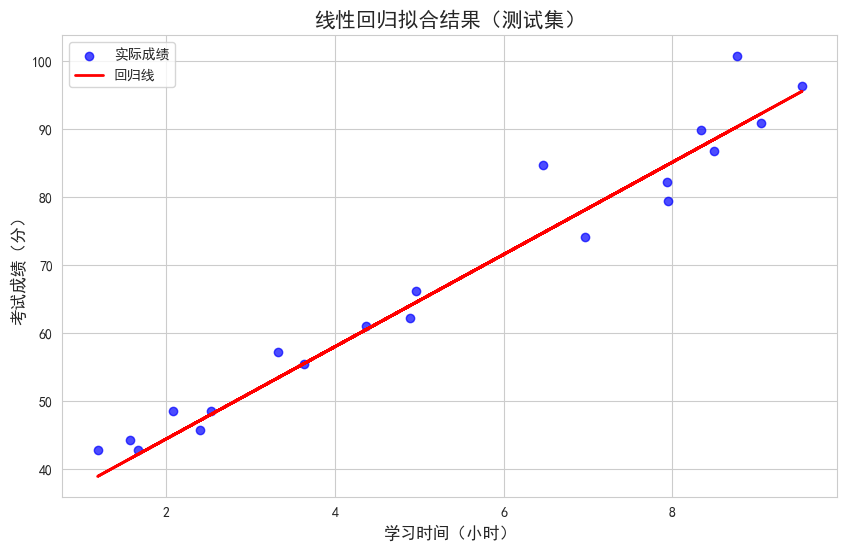

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(X_test,Y_test,color='blue',label='实际成绩',alpha=0.7)

plt.plot(X_test,Y_pred,color='red',linewidth=2,label='回归线')

plt.title('线性回归拟合结果（测试集）',fontsize=15)

plt.xlabel('学习时间（小时）',fontsize=12)
plt.ylabel('考试成绩（分）',fontsize=12)

plt.legend()
plt.show()

残差图分析

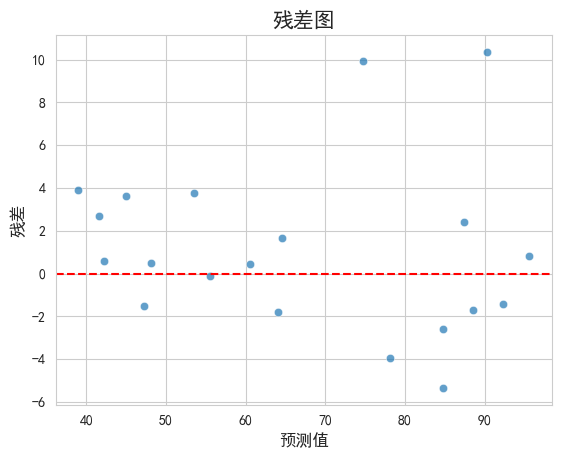

In [14]:
# 计算残差
residuals = Y_test - Y_pred
sns.scatterplot(
    x = Y_pred,
    y = residuals,
    alpha=0.7
)

plt.axhline(y=0,color='red',linestyle='--')

plt.title('残差图',fontsize=15)
plt.xlabel('预测值',fontsize=12)
plt.ylabel('残差',fontsize=12)
plt.show()

使用模型进行新的预测

In [16]:
new_study_hours = np.array([[6.5]])

predicted_scores = model.predict(new_study_hours)

print(f'预测:学习6.5小时的考试成绩为{predicted_scores[0]:.2f}分')

预测:学习6.5小时的考试成绩为74.99分


d:\modeling\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
